<h1>Intro to Monte Carlo Simulations</h1>
In this script, we are introducing how to code a Monte Carlo simulation on a stock portfolio


In [7]:
import math

#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import yfinance as yf

In [8]:
from scipy.optimize import minimize
# 1. Setup and Data Download
tickers = ['AMZN', 'CEG', 'NFLX', 'QQQI', 'SPYG', 'VXUS', 'VTI']
time = "Now" #options, Jan, Now
T = 365 #timeframe in days
look_back = 365

match time:
    case "Jan":
        endDate = "2026-01-29"
        endDate = dt.datetime.strptime(endDate, "%Y-%m-%d").date()
    case "Now":
        endDate = dt.datetime.now()

startDate = endDate - dt.timedelta(days = look_back)

data = yf.download(tickers, start=startDate, end=endDate)['Close']
returns = data.pct_change().dropna()

# 2. Calculate Annualized Statistics
# 252 trading days in a year
mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252
risk_free_rate = 0.04  # Assuming 4% risk-free rate (e.g., Treasury Yield)

# 3. Define Optimization Functions
def get_portfolio_stats(weights):
    """Calculates annualized return, volatility, and Sharpe ratio."""
    weights = np.array(weights)
    port_ret = np.sum(mean_returns * weights)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe = (port_ret - risk_free_rate) / port_vol
    return port_ret, port_vol, sharpe

def neg_sharpe(weights):
    """Objective function to minimize: the negative Sharpe Ratio."""
    return -get_portfolio_stats(weights)[2]

# 4. Constraints and Bounds
# Constraint: Sum of weights must be 1.0 (100%)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

# Bounds: Each weight must be between 0 and 1 (No short selling)
#bounds = tuple((0, 1) for _ in range(len(tickers)))
n_assets = len(tickers)
bounds = [(0, 0.4) for _ in range(n_assets)]

# Initial Guess: Equal weight distribution
init_guess = [1.0 / len(tickers)] * len(tickers)

# 5. Run the Optimizer (SLSQP Method)
opt_results = minimize(neg_sharpe, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)

# 6. Extract Results
best_weights = opt_results.x
opt_ret, opt_vol, opt_sharpe = get_portfolio_stats(best_weights)

# --- Display Output ---
print("-" * 30)
print("OPTIMAL PORTFOLIO WEIGHTS")
print("-" * 30)
for ticker, weight in zip(tickers, best_weights):
    print(f"{ticker}: {weight:.2%}")

print("\n" + "-" * 30)
print("EXPECTED PERFORMANCE")
print("-" * 30)
print(f"Annual Return:     {opt_ret:.2%}")
print(f"Annual Volatility: {opt_vol:.2%}")
print(f"Sharpe Ratio:      {opt_sharpe:.2f}")

[*********************100%***********************]  7 of 7 completed

------------------------------
OPTIMAL PORTFOLIO WEIGHTS
------------------------------
AMZN: 0.00%
CEG: 1.80%
NFLX: 2.65%
QQQI: 15.55%
SPYG: 0.00%
VXUS: 40.00%
VTI: 40.00%

------------------------------
EXPECTED PERFORMANCE
------------------------------
Annual Return:     30.30%
Annual Volatility: 12.98%
Sharpe Ratio:      2.03


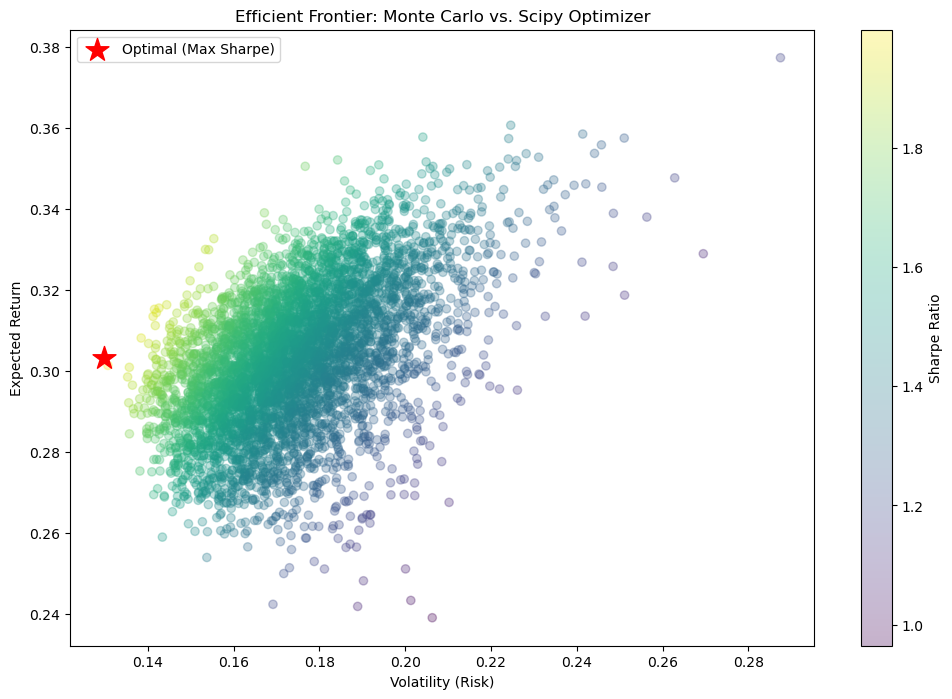

In [9]:
# 1. Generate random portfolios for the "Cloud" (Monte Carlo)
num_portfolios = 5000
all_weights = np.zeros((num_portfolios, len(tickers)))
ret_arr = np.zeros(num_portfolios)
vol_arr = np.zeros(num_portfolios)
sharpe_arr = np.zeros(num_portfolios)

for i in range(num_portfolios):
    # Create random weights
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)
    all_weights[i,:] = weights

    # Calculate stats
    p_ret, p_vol, p_sharpe = get_portfolio_stats(weights)
    ret_arr[i] = p_ret
    vol_arr[i] = p_vol
    sharpe_arr[i] = p_sharpe

# 2. Plotting
plt.figure(figsize=(12, 8))
plt.scatter(vol_arr, ret_arr, c=sharpe_arr, cmap='viridis', alpha=0.3)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')

# 3. Add the Optimal Portfolio found by Scipy
plt.scatter(opt_vol, opt_ret, color='red', marker='*', s=300, label='Optimal (Max Sharpe)')

plt.title('Efficient Frontier: Monte Carlo vs. Scipy Optimizer')
plt.legend(labelspacing=0.8)
plt.show()